In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

In [15]:
# Load data
df = pd.read_csv('raw/Interval.tsv', sep='\t')
print(f"Loaded {len(df)} rows with {len(df.columns)} columns")

/tmp/ipykernel_23968/2024057585.py:2: DtypeWarning: Columns (46186,46187,46188,46189,46190,46191,46192,46193,46194,46195,46196,46197,46198,46199,46200,46201,46202,46203,46204,46206,46207,46208,46209,46210,46211,46212,46213,46214,46215,46216,46217,46218,46219,46220,46221,46222,46223,46224,46225,46226,46227,46228,46229,46230,46231,46232,46233,46234,46235,46236,46237,46240,46241,46242,46243,46244,46245,46246,46247,46248,46249,46250,46251,46252,46253,46254,46255,46256,46257,46258,46259,46260,46261,46262,46263,46264,46265,46266,46267,46268,46269,46270,46271,46272,46273,46274,46275,46276,46277,46278,46279,46280,46281,46282,46283,46284,46285,46286,46287,46288,46289,46290,46291,46292,46293,46294,46295,46296,46297,46298,46299,46300,46301,46302,46303,46304,46305,46306,46307,46308,46309,46310,46311,46312,46313,46314,46315,46316,46317,46318,46319,46320,46321,46322,46323,46324,46325,46326,46327,46328,46329,46330,46331,46332,46333,46334,46335,46336,46337,46338,46339,46340,46341,46342,46343,46344,463

Loaded 594 rows with 48666 columns


## Fixation Analysis: Oscuro vs Claro

This analysis calculates and compares total fixations between "Oscuro" (dark mode) and "Claro" (light mode) conditions.

In [16]:
# Classify conditions and filter data (exclude combined media to avoid double-counting)
df['Condition'] = df['Media'].apply(lambda x: 'Oscuro' if pd.notna(x) and 'Oscuro' in str(x) 
                                     else ('Claro' if pd.notna(x) and 'Claro' in str(x) else 'Other'))
df['Is_Single_Media'] = df['Media'].apply(lambda x: pd.isna(x) or ',' not in str(x))

print(f"Conditions found: {df['Condition'].value_counts().to_dict()}")
print(f"Single media rows: {df['Is_Single_Media'].sum()}, Combined: {(~df['Is_Single_Media']).sum()}")

Conditions found: {'Other': 492, 'Claro': 51, 'Oscuro': 51}
Single media rows: 560, Combined: 34


In [17]:
# Calculate total fixations (single media only to avoid double-counting)
df_filtered = df[(df['Condition'].isin(['Oscuro', 'Claro'])) & df['Is_Single_Media']].copy()
fixation_cols = [col for col in df.columns if 'Number_of_fixation' in col]
df_filtered['Total_Fixations'] = df_filtered[fixation_cols].sum(axis=1)

# Summary statistics
fixation_summary = df_filtered.groupby('Condition')['Total_Fixations'].agg([
    ('Total_Fixations', 'sum'),
    ('Mean_Fixations_per_Interval', 'mean'),
    ('Std_Fixations', 'std'),
    ('Median_Fixations', 'median'),
    ('Number_of_Intervals', 'count')
])

print("FIXATION SUMMARY: Oscuro vs Claro (Single Media Only)")
print("="*70)
print(fixation_summary)
print("="*70)

FIXATION SUMMARY: Oscuro vs Claro (Single Media Only)
           Total_Fixations  Mean_Fixations_per_Interval  Std_Fixations  \
Condition                                                                
Claro               7827.0                   230.205882     167.766212   
Oscuro              8277.0                   243.441176     162.655090   

           Median_Fixations  Number_of_Intervals  
Condition                                         
Claro                 137.5                   34  
Oscuro                178.0                   34  


In [18]:
# Statistical comparison
oscuro_fixations = df_filtered[df_filtered['Condition'] == 'Oscuro']['Total_Fixations']
claro_fixations = df_filtered[df_filtered['Condition'] == 'Claro']['Total_Fixations']
t_stat, p_value = stats.ttest_ind(oscuro_fixations, claro_fixations, nan_policy='omit')

total_oscuro = fixation_summary.loc['Oscuro', 'Total_Fixations']
total_claro = fixation_summary.loc['Claro', 'Total_Fixations']
percent_diff = ((total_oscuro - total_claro) / total_claro) * 100

print(f"\nt-test: t={t_stat:.4f}, p={p_value:.6f} ({'Significant' if p_value < 0.05 else 'Not Significant'})")
print(f"Difference: Oscuro has {percent_diff:+.2f}% {'more' if percent_diff > 0 else 'fewer'} fixations than Claro")


t-test: t=0.3303, p=0.742243 (Not Significant)
Difference: Oscuro has +5.75% more fixations than Claro


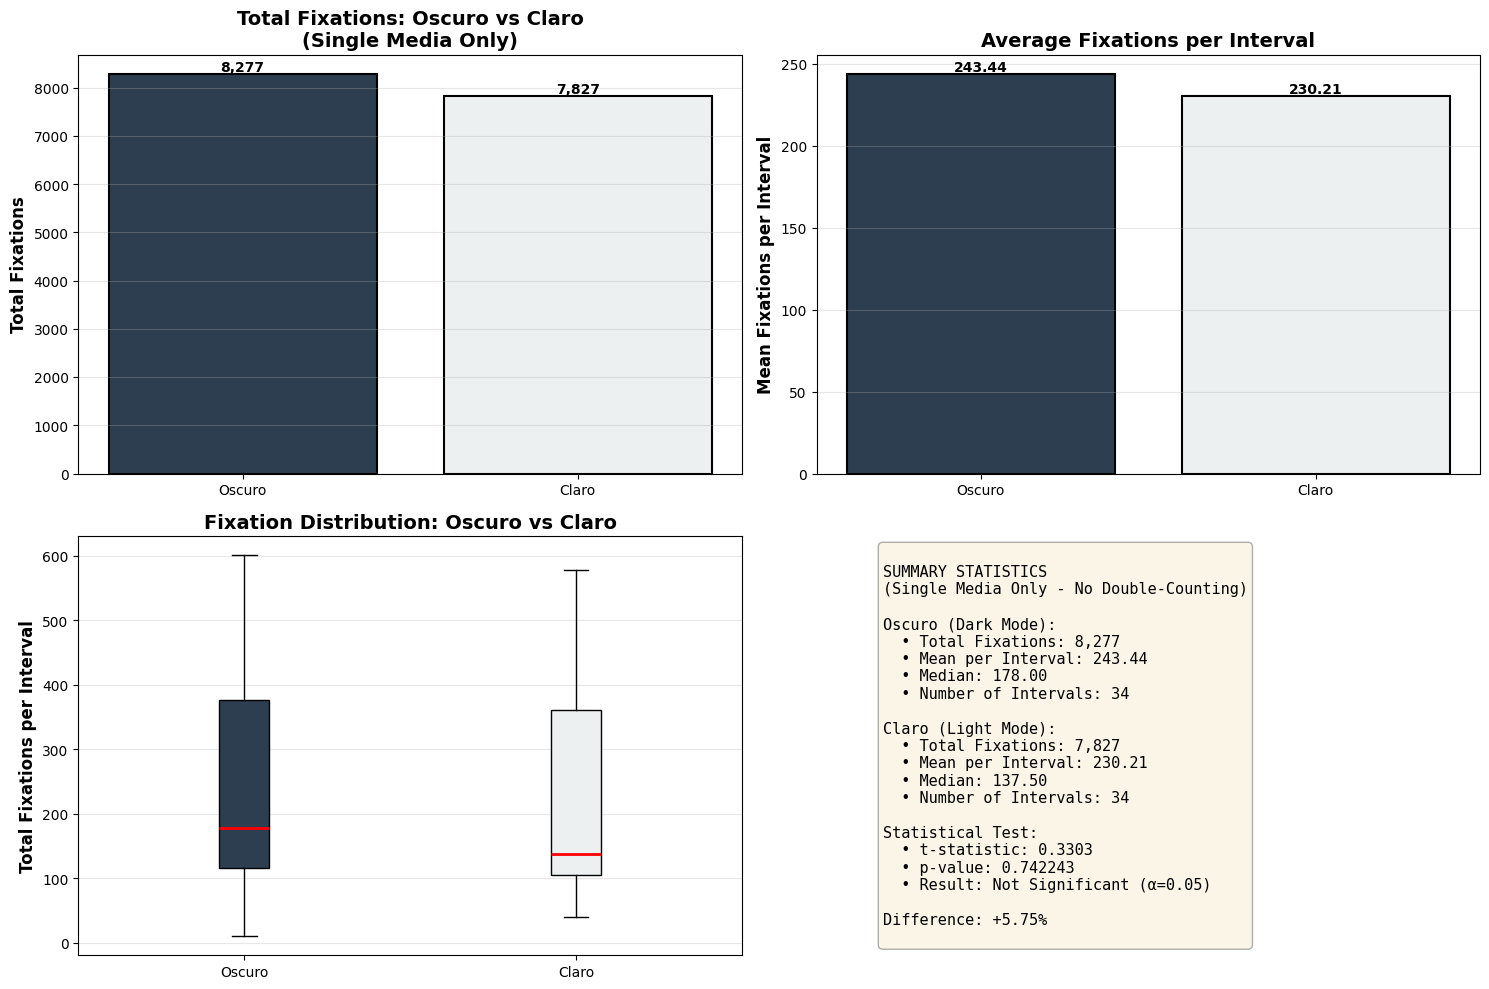


✓ Visualization saved to: output/fixation_comparison_oscuro_vs_claro.png
✓ Analysis excludes combined media rows to prevent double-counting


In [19]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Bar chart - Total Fixations
ax1 = axes[0, 0]
conditions = ['Oscuro', 'Claro']
totals = [fixation_summary.loc[c, 'Total_Fixations'] for c in conditions]
colors = ['#2c3e50', '#ecf0f1']
ax1.bar(conditions, totals, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Total Fixations', fontsize=12, fontweight='bold')
ax1.set_title('Total Fixations: Oscuro vs Claro\n(Single Media Only)', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
for i, v in enumerate(totals):
    ax1.text(i, v, f'{int(v):,}', ha='center', va='bottom', fontweight='bold')

# 2. Bar chart - Mean Fixations per Interval
ax2 = axes[0, 1]
means = [fixation_summary.loc[c, 'Mean_Fixations_per_Interval'] for c in conditions]
ax2.bar(conditions, means, color=colors, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Mean Fixations per Interval', fontsize=12, fontweight='bold')
ax2.set_title('Average Fixations per Interval', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
for i, v in enumerate(means):
    ax2.text(i, v, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')

# 3. Box plot - Distribution comparison
ax3 = axes[1, 0]
data_to_plot = [oscuro_fixations, claro_fixations]
bp = ax3.boxplot(data_to_plot, tick_labels=conditions, patch_artist=True,
                 medianprops=dict(color='red', linewidth=2),
                 boxprops=dict(facecolor='lightblue', edgecolor='black'))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax3.set_ylabel('Total Fixations per Interval', fontsize=12, fontweight='bold')
ax3.set_title('Fixation Distribution: Oscuro vs Claro', fontsize=14, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# 4. Summary text
ax4 = axes[1, 1]
ax4.axis('off')
summary_text = f"""
SUMMARY STATISTICS
(Single Media Only - No Double-Counting)

Oscuro (Dark Mode):
  • Total Fixations: {int(total_oscuro):,}
  • Mean per Interval: {fixation_summary.loc['Oscuro', 'Mean_Fixations_per_Interval']:.2f}
  • Median: {fixation_summary.loc['Oscuro', 'Median_Fixations']:.2f}
  • Number of Intervals: {int(fixation_summary.loc['Oscuro', 'Number_of_Intervals'])}

Claro (Light Mode):
  • Total Fixations: {int(total_claro):,}
  • Mean per Interval: {fixation_summary.loc['Claro', 'Mean_Fixations_per_Interval']:.2f}
  • Median: {fixation_summary.loc['Claro', 'Median_Fixations']:.2f}
  • Number of Intervals: {int(fixation_summary.loc['Claro', 'Number_of_Intervals'])}

Statistical Test:
  • t-statistic: {t_stat:.4f}
  • p-value: {p_value:.6f}
  • Result: {'Significant' if p_value < 0.05 else 'Not Significant'} (α=0.05)
  
Difference: {percent_diff:+.2f}%
"""
ax4.text(0.1, 0.5, summary_text, fontsize=11, family='monospace',
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.savefig('output/fixation_comparison_oscuro_vs_claro.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved to: output/fixation_comparison_oscuro_vs_claro.png")
print("✓ Analysis excludes combined media rows to prevent double-counting")